# Customer Churn Prediction - Machine Learning Experimentation

This notebook trains, tunes, evaluates, compares, and saves multiple classification models for customer churn prediction using the selected feature-ready dataset.

In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, RidgeClassifier, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Binarizer, MinMaxScaler, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'customer_churn_selected.csv'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'model_experimentation'
PLOT_DIR = ARTIFACT_DIR / 'plots'
REPORT_DIR = ARTIFACT_DIR / 'reports'
MODEL_DIR = ARTIFACT_DIR / 'models'
for directory in [ARTIFACT_DIR, PLOT_DIR, REPORT_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset path: {DATA_PATH}')
print(f'Artifacts path: {ARTIFACT_DIR}')

Project root: c:\Users\AHMED SAMIR\Desktop\AI&Data_Science\DS_project\customer-churn-prediction
Dataset path: c:\Users\AHMED SAMIR\Desktop\AI&Data_Science\DS_project\customer-churn-prediction\data\cleaned\customer_churn_selected.csv
Artifacts path: c:\Users\AHMED SAMIR\Desktop\AI&Data_Science\DS_project\customer-churn-prediction\artifacts\model_experimentation


Dataset loaded successfully
Shape: (7032, 11)


,tenure,MonthlyCharges,TotalCharges,Contract_Two year,Contract_One year,PaymentMethod_Electronic check,InternetService_Fiber optic,OnlineSecurity_Yes,TechSupport_Yes,Partner,Churn
0,1,29.85,29.85,0,0,1,0,0,0,1,0
1,34,56.95,1889.50,0,1,0,0,1,0,0,0
2,2,53.85,108.15,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,0,1,0,0,1,1,0,0
4,2,70.70,151.65,0,0,1,1,0,0,0,1


,proportion
Churn,
0,0.734215
1,0.265785


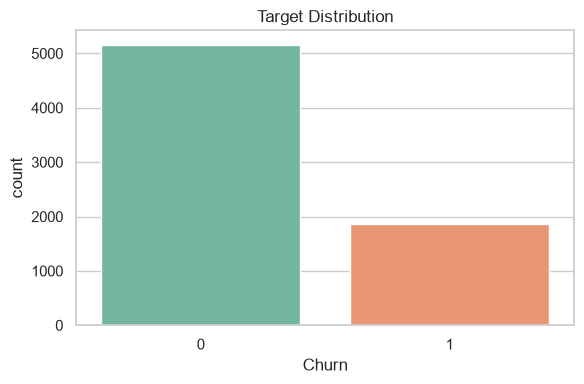

In [2]:
df = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully')
print('Shape:', df.shape)
display(df.head())

target_distribution = df['Churn'].value_counts(normalize=True).rename('proportion').to_frame()
display(target_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Target Distribution')
plt.tight_layout()
plt.show()

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)
feature_names = X.columns.tolist()
numeric_features = feature_names.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Positive class rate in train:', round(y_train.mean(), 4))
print('Positive class rate in test:', round(y_test.mean(), 4))

Train shape: (5625, 10)
Test shape: (1407, 10)
Positive class rate in train: 0.2658
Positive class rate in test: 0.2658


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def build_preprocessor(scale_mode='standard'):
    if scale_mode == 'standard':
        transformer = StandardScaler()
    elif scale_mode == 'minmax':
        transformer = MinMaxScaler()
    elif scale_mode == 'binary':
        transformer = Pipeline([
            ('scaler', MinMaxScaler()),
            ('binarizer', Binarizer(threshold=0.5)),
        ])
    else:
        transformer = 'passthrough'

    return ColumnTransformer(
        transformers=[('num', transformer, numeric_features)],
        remainder='drop',
        verbose_feature_names_out=False,
    )

def get_positive_scores(estimator, data):
    if hasattr(estimator, 'predict_proba'):
        return estimator.predict_proba(data)[:, 1]
    if hasattr(estimator, 'decision_function'):
        return estimator.decision_function(data)
    return estimator.predict(data)

def safe_log_loss(y_true, y_score):
    try:
        if y_score.ndim == 1:
            clipped = np.clip(y_score, 1e-6, 1 - 1e-6)
            stacked = np.column_stack([1 - clipped, clipped])
            return log_loss(y_true, stacked)
        return log_loss(y_true, y_score)
    except Exception:
        return np.nan

def make_adaboost():
    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    try:
        return AdaBoostClassifier(estimator=stump, random_state=RANDOM_STATE)
    except TypeError:
        return AdaBoostClassifier(base_estimator=stump, random_state=RANDOM_STATE)

def make_bagging(base_estimator=None):
    kwargs = dict(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    if base_estimator is None:
        base_estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
    try:
        return BaggingClassifier(estimator=base_estimator, **kwargs)
    except TypeError:
        return BaggingClassifier(base_estimator=base_estimator, **kwargs)

def make_model_specs():
    specs = [
        dict(
            name='Logistic Regression',
            estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
            scale='standard',
            params={
                'model__C': [0.01, 0.1, 1.0, 10.0],
                'model__solver': ['lbfgs', 'liblinear'],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=8,
            notes='Linear baseline with calibrated probabilities',
        ),
        dict(
            name='SGD Classifier',
            estimator=SGDClassifier(random_state=RANDOM_STATE, max_iter=5000, tol=1e-3),
            scale='standard',
            params={
                'model__loss': ['log_loss', 'hinge'],
                'model__alpha': [1e-5, 1e-4, 1e-3],
                'model__penalty': ['l2', 'l1', 'elasticnet'],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=8,
            notes='Fast linear online learner',
        ),
        dict(
            name='Ridge Classifier',
            estimator=RidgeClassifier(),
            scale='standard',
            params={
                'model__alpha': [0.1, 1.0, 10.0],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=6,
            notes='Regularized linear margin model',
        ),
        dict(
            name='Passive Aggressive',
            estimator=PassiveAggressiveClassifier(random_state=RANDOM_STATE, max_iter=5000, tol=1e-3),
            scale='standard',
            params={
                'model__C': [0.01, 0.1, 1.0, 10.0],
                'model__loss': ['hinge', 'squared_hinge'],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=8,
            notes='Aggressive large-margin classifier',
        ),
        dict(
            name='Decision Tree',
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            scale='none',
            params={
                'model__max_depth': [None, 3, 5, 8, 12],
                'model__min_samples_split': [2, 5, 10],
                'model__min_samples_leaf': [1, 2, 4],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=10,
            notes='Highly interpretable tree baseline',
        ),
        dict(
            name='Random Forest',
            estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            scale='none',
            params={
                'model__n_estimators': [200, 400],
                'model__max_depth': [None, 8, 12, 20],
                'model__max_features': ['sqrt', 'log2'],
                'model__min_samples_leaf': [1, 2, 4],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=10,
            notes='Strong non-linear tree ensemble',
        ),
        dict(
            name='Extra Trees',
            estimator=ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            scale='none',
            params={
                'model__n_estimators': [200, 400],
                'model__max_depth': [None, 8, 12, 20],
                'model__max_features': ['sqrt', 'log2'],
                'model__min_samples_leaf': [1, 2, 4],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=10,
            notes='Randomized tree ensemble with low bias',
        ),
        dict(
            name='AdaBoost',
            estimator=make_adaboost(),
            scale='none',
            params={
                'model__n_estimators': [50, 100, 200],
                'model__learning_rate': [0.01, 0.1, 1.0],
            },
            n_iter=8,
            notes='Boosting with shallow trees',
        ),
        dict(
            name='Gradient Boosting',
            estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
            scale='none',
            params={
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.03, 0.05, 0.1],
                'model__max_depth': [2, 3],
                'model__subsample': [0.8, 1.0],
            },
            n_iter=10,
            notes='Classic boosting baseline',
        ),
        dict(
            name='HistGradientBoosting',
            estimator=HistGradientBoostingClassifier(random_state=RANDOM_STATE),
            scale='none',
            params={
                'model__learning_rate': [0.03, 0.05, 0.1],
                'model__max_depth': [None, 3, 5, 8],
                'model__max_iter': [100, 200],
                'model__min_samples_leaf': [20, 30, 50],
            },
            n_iter=10,
            notes='Fast histogram-based boosting',
        ),
        dict(
            name='Linear SVM',
            estimator=LinearSVC(random_state=RANDOM_STATE, max_iter=5000),
            scale='standard',
            params={
                'model__C': [0.01, 0.1, 1.0, 10.0],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=8,
            notes='Margin-based linear classifier',
        ),
        dict(
            name='RBF SVM',
            estimator=SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
            scale='standard',
            params={
                'model__C': [0.1, 1.0, 10.0],
                'model__gamma': ['scale', 0.1, 0.01],
                'model__class_weight': [None, 'balanced'],
            },
            n_iter=9,
            notes='Non-linear kernel classifier',
        ),
        dict(
            name='Gaussian NB',
            estimator=GaussianNB(),
            scale='standard',
            params={
                'model__var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8],
            },
            n_iter=4,
            notes='Probabilistic baseline',
        ),
        dict(
            name='Bernoulli NB',
            estimator=BernoulliNB(),
            scale='binary',
            params={
                'model__alpha': [0.1, 0.5, 1.0],
                'model__binarize': [0.25, 0.5, 0.75],
            },
            n_iter=6,
            notes='Binary-feature probabilistic baseline',
        ),
        dict(
            name='KNN',
            estimator=KNeighborsClassifier(),
            scale='standard',
            params={
                'model__n_neighbors': [3, 5, 7, 9, 11],
                'model__weights': ['uniform', 'distance'],
                'model__p': [1, 2],
            },
            n_iter=10,
            notes='Instance-based classifier',
        ),
        dict(
            name='MLP Classifier',
            estimator=MLPClassifier(random_state=RANDOM_STATE, max_iter=600),
            scale='standard',
            params={
                'model__hidden_layer_sizes': [(32,), (64,), (64, 32)],
                'model__alpha': [1e-4, 1e-3, 1e-2],
                'model__learning_rate_init': [1e-3, 1e-2],
            },
            n_iter=9,
            notes='Neural network baseline',
        ),
        dict(
            name='Bagging Classifier',
            estimator=make_bagging(),
            scale='none',
            params={
                'model__n_estimators': [25, 50, 100],
                'model__max_samples': [0.7, 0.85, 1.0],
                'model__max_features': [0.7, 0.85, 1.0],
            },
            n_iter=9,
            notes='Bootstrap aggregation ensemble',
        ),
    ]

    if XGBClassifier is not None:
        specs.append(
            dict(
                name='XGBoost',
                estimator=XGBClassifier(
                    random_state=RANDOM_STATE,
                    n_estimators=300,
                    eval_metric='logloss',
                    tree_method='hist',
                    n_jobs=-1,
                ),
                scale='none',
                params={
                    'model__n_estimators': [200, 300, 400],
                    'model__max_depth': [3, 4, 6],
                    'model__learning_rate': [0.03, 0.05, 0.1],
                    'model__subsample': [0.8, 1.0],
                    'model__colsample_bytree': [0.8, 1.0],
                },
                n_iter=10,
                notes='Optional gradient boosting library',
            )
        )

    if LGBMClassifier is not None:
        specs.append(
            dict(
                name='LightGBM',
                estimator=LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                scale='none',
                params={
                    'model__n_estimators': [200, 300, 400],
                    'model__num_leaves': [15, 31, 63],
                    'model__learning_rate': [0.03, 0.05, 0.1],
                    'model__subsample': [0.8, 1.0],
                },
                n_iter=10,
                notes='Optional gradient boosting library',
            )
        )

    if CatBoostClassifier is not None:
        specs.append(
            dict(
                name='CatBoost',
                estimator=CatBoostClassifier(
                    random_state=RANDOM_STATE,
                    verbose=False
                ),
                scale='none',
                params={
                    'model__iterations': [200, 300, 400],
                    'model__depth': [4, 6, 8],
                    'model__learning_rate': [0.03, 0.05, 0.1],
                },
                n_iter=9,
                notes='Optional gradient boosting library',
            )
        )

    return specs

model_specs = make_model_specs()
print('Number of model candidates:', len(model_specs))

Number of model candidates: 18


In [5]:
def make_voting():
    estimators = [
        ('lr', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
    return VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)


def make_stacking():
    estimators = [
        ('lr', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
    final_estimator = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    return StackingClassifier(
        estimators=estimators,
        final_estimator=final_estimator,
        passthrough=False,
        cv=5,
        n_jobs=-1,
    )


model_specs.extend([
    dict(
        name='Voting Classifier',
        estimator=make_voting(),
        scale='standard',
        params={
            'model__weights': [(1, 1, 1), (2, 1, 1), (1, 2, 1)],
        },
        n_iter=3,
        notes='Soft-voting ensemble built from strong base learners',
    ),
    dict(
        name='Stacking Classifier',
        estimator=make_stacking(),
        scale='standard',
        params={
            'model__final_estimator__C': [0.1, 1.0, 10.0],
            'model__passthrough': [False, True],
        },
        n_iter=6,
        notes='Stacked ensemble using logistic meta-learner',
    ),
])

print('Ensemble models added:', ['Voting Classifier', 'Stacking Classifier'])

Ensemble models added: ['Voting Classifier', 'Stacking Classifier']


In [6]:
results = []
trained_models = {}
classification_reports = {}

cm_path = PLOT_DIR / 'confusion_matrices'
roc_path = PLOT_DIR / 'roc_curves'
pr_path = PLOT_DIR / 'precision_recall_curves'
report_path = REPORT_DIR / 'classification_reports'
for directory in [cm_path, roc_path, pr_path, report_path]:
    directory.mkdir(parents=True, exist_ok=True)

for spec in model_specs:
    print()
    print('=' * 90)
    print(f"Training: {spec['name']}")

    if spec['scale'] == 'standard':
        preprocessor = build_preprocessor('standard')
    elif spec['scale'] == 'minmax':
        preprocessor = build_preprocessor('minmax')
    elif spec['scale'] == 'binary':
        preprocessor = build_preprocessor('binary')
    else:
        preprocessor = build_preprocessor('none')

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', spec['estimator']),
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=spec['params'],
        n_iter=spec['n_iter'],
        scoring='roc_auc',
        n_jobs=-1,
        cv=cv,
        random_state=RANDOM_STATE,
        refit=True,
        verbose=0,
    )

    start_train = time.perf_counter()
    search.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    best_estimator = search.best_estimator_
    start_pred = time.perf_counter()
    y_pred = best_estimator.predict(X_test)
    prediction_time = time.perf_counter() - start_pred

    y_score = get_positive_scores(best_estimator, X_test)
    y_prob = best_estimator.predict_proba(X_test)[:, 1] if hasattr(best_estimator, 'predict_proba') else None

    try:
        roc_auc = roc_auc_score(y_test, y_score)
    except Exception:
        roc_auc = np.nan

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    classification_reports[spec['name']] = pd.DataFrame(report).T
    ll = safe_log_loss(y_test, y_prob) if y_prob is not None else np.nan

    results.append({
        'Model Name': spec['name'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc,
        'Log Loss': ll,
        'Matthews Corrcoef': matthews_corrcoef(y_test, y_pred),
        'Cohen Kappa': cohen_kappa_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'CV Score': search.best_score_,
        'Training Time': train_time,
        'Prediction Time': prediction_time,
        'Best Parameters': search.best_params_,
        'Notes': spec['notes'],
    })

    trained_models[spec['name']] = {
        'search': search,
        'estimator': best_estimator,
        'y_pred': y_pred,
        'y_score': y_score,
        'y_prob': y_prob,
    }

    model_slug = spec['name'].lower().replace(' ', '_').replace('-', '_')

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix - {spec['name']}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    fig.tight_layout()
    fig.savefig(cm_path / f'{model_slug}.png', dpi=160, bbox_inches='tight')
    plt.close(fig)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f"ROC Curve - {spec['name']}")
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    fig.tight_layout()
    fig.savefig(roc_path / f'{model_slug}.png', dpi=160, bbox_inches='tight')
    plt.close(fig)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision)
    ax.set_title(f"Precision-Recall Curve - {spec['name']}")
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    fig.tight_layout()
    fig.savefig(pr_path / f'{model_slug}.png', dpi=160, bbox_inches='tight')
    plt.close(fig)

    classification_reports[spec['name']].to_csv(report_path / f'{model_slug}.csv')

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=['ROC-AUC', 'F1 Score', 'CV Score', 'Balanced Accuracy'],
    ascending=[False, False, False, False],
)

display(results_df[['Model Name', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV Score', 'Training Time', 'Prediction Time']])


Training: Logistic Regression

Training: SGD Classifier

Training: Ridge Classifier

Training: Passive Aggressive

Training: Decision Tree

Training: Random Forest

Training: Extra Trees

Training: AdaBoost

Training: Gradient Boosting

Training: HistGradientBoosting

Training: Linear SVM

Training: RBF SVM

Training: Gaussian NB

Training: Bernoulli NB

Training: KNN

Training: MLP Classifier

Training: Bagging Classifier

Training: XGBoost

Training: Voting Classifier

Training: Stacking Classifier


,Model Name,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Score,Training Time,Prediction Time
9,HistGradientBoosting,0.795309,0.644295,0.513369,0.571429,0.837980,0.846399,9.133562,0.014105
7,AdaBoost,0.796020,0.652632,0.497326,0.564492,0.836712,0.843439,10.255510,0.062425
8,Gradient Boosting,0.789623,0.630872,0.502674,0.559524,0.836484,0.845782,11.941275,0.003028
19,Stacking Classifier,0.786070,0.623729,0.491979,0.550075,0.835914,0.845608,133.915945,0.065674
5,Random Forest,0.742004,0.509532,0.786096,0.618297,0.834859,0.843061,31.002566,0.107934
17,XGBoost,0.786070,0.615142,0.521390,0.564399,0.834732,0.845889,15.873403,0.006573
18,Voting Classifier,0.787491,0.621359,0.513369,0.562225,0.834252,0.843751,11.363411,0.055592
15,MLP Classifier,0.791045,0.632450,0.510695,0.565089,0.830361,0.840693,41.539266,0.002305
6,Extra Trees,0.728500,0.493289,0.786096,0.606186,0.830343,0.840550,23.053494,0.092827
0,Logistic Regression,0.784648,0.614887,0.508021,0.556369,0.830253,0.839013,5.025474,0.005558


,Model Name,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Score,Training Time,Prediction Time,Notes
9,HistGradientBoosting,0.795309,0.644295,0.513369,0.571429,0.837980,0.846399,9.133562,0.014105,Fast histogram-based boosting
7,AdaBoost,0.796020,0.652632,0.497326,0.564492,0.836712,0.843439,10.255510,0.062425,Boosting with shallow trees
8,Gradient Boosting,0.789623,0.630872,0.502674,0.559524,0.836484,0.845782,11.941275,0.003028,Classic boosting baseline
19,Stacking Classifier,0.786070,0.623729,0.491979,0.550075,0.835914,0.845608,133.915945,0.065674,Stacked ensemble using logistic meta-learner
5,Random Forest,0.742004,0.509532,0.786096,0.618297,0.834859,0.843061,31.002566,0.107934,Strong non-linear tree ensemble
17,XGBoost,0.786070,0.615142,0.521390,0.564399,0.834732,0.845889,15.873403,0.006573,Optional gradient boosting library
18,Voting Classifier,0.787491,0.621359,0.513369,0.562225,0.834252,0.843751,11.363411,0.055592,Soft-voting ensemble built from strong base le...
15,MLP Classifier,0.791045,0.632450,0.510695,0.565089,0.830361,0.840693,41.539266,0.002305,Neural network baseline
6,Extra Trees,0.728500,0.493289,0.786096,0.606186,0.830343,0.840550,23.053494,0.092827,Randomized tree ensemble with low bias
0,Logistic Regression,0.784648,0.614887,0.508021,0.556369,0.830253,0.839013,5.025474,0.005558,Linear baseline with calibrated probabilities


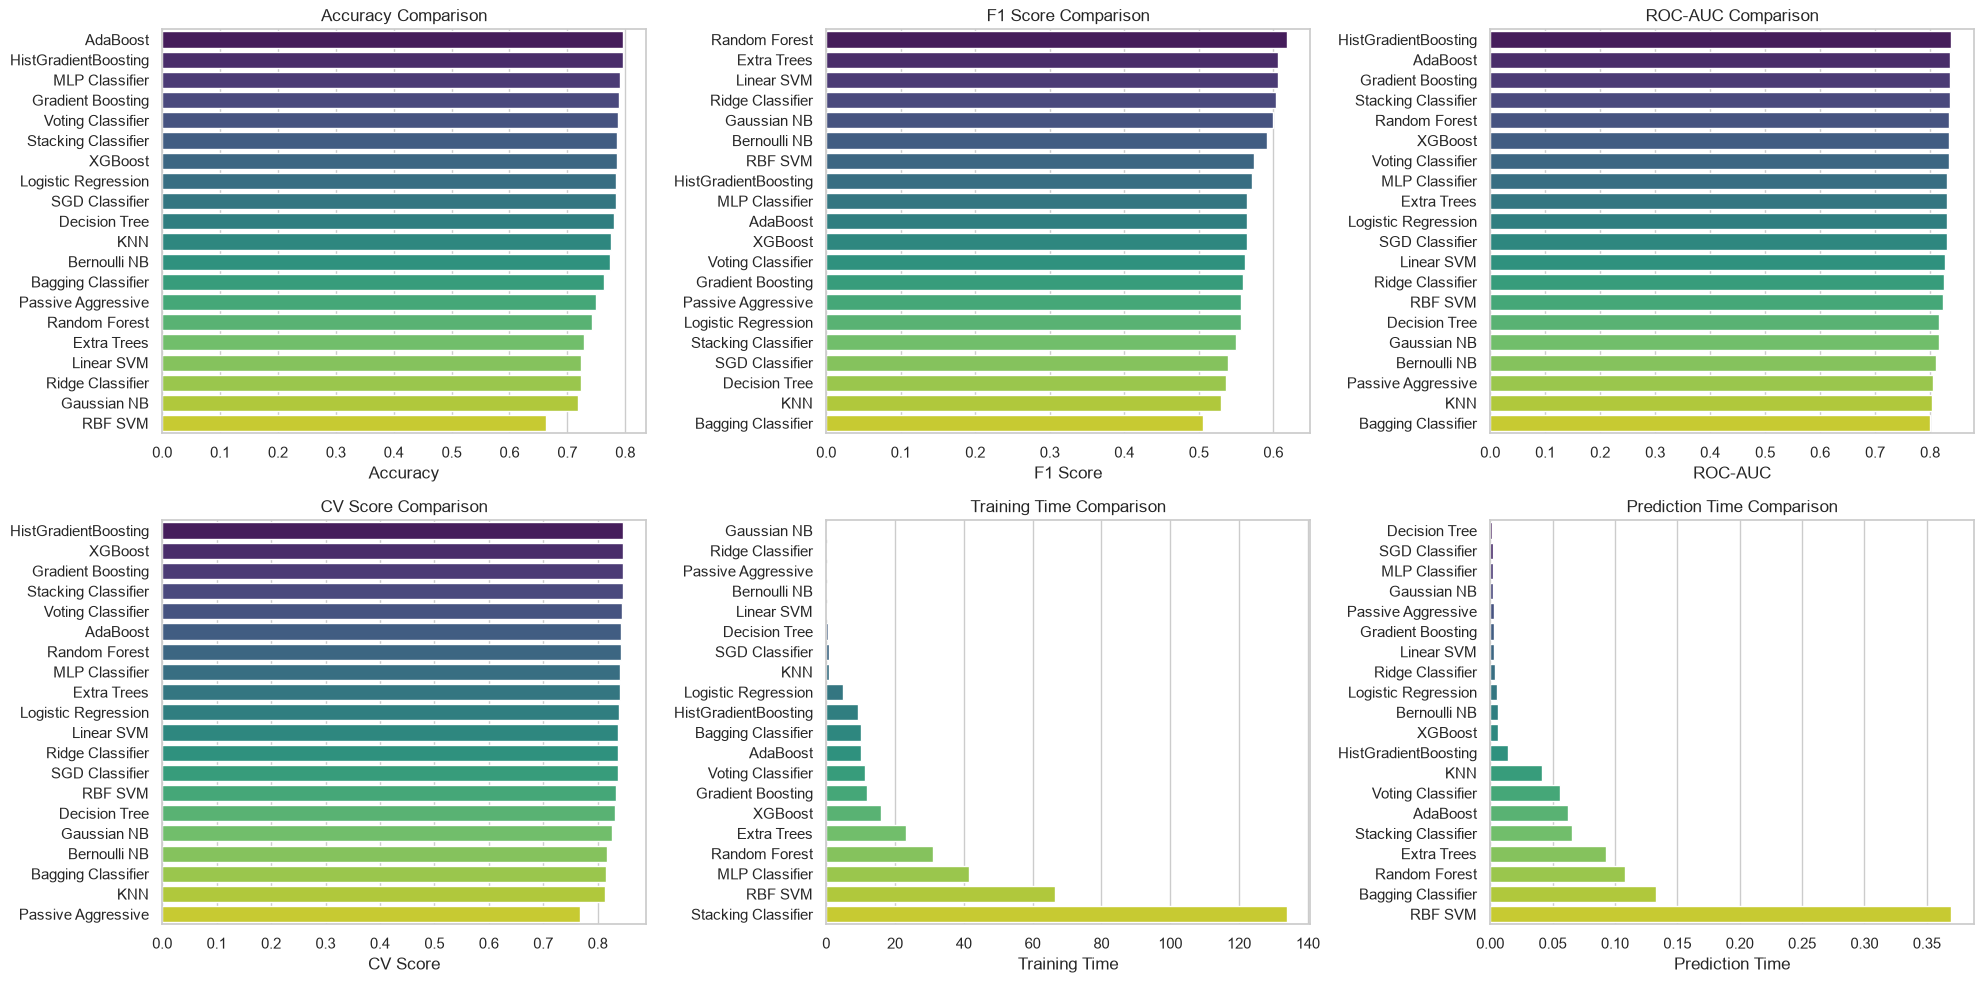

Best model selected: HistGradientBoosting
Best parameters: {'model__min_samples_leaf': 30, 'model__max_iter': 200, 'model__max_depth': 3, 'model__learning_rate': 0.03}


In [7]:
registry_df = results_df.copy()
registry_df['Best Parameters'] = registry_df['Best Parameters'].apply(lambda value: json.dumps(value, default=str))
registry_df['Top Model'] = False
registry_df.loc[registry_df.index[0], 'Top Model'] = True

display(registry_df[['Model Name', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV Score', 'Training Time', 'Prediction Time', 'Notes']])
registry_df.to_csv(ARTIFACT_DIR / 'model_registry.csv', index=False)
results_df.to_csv(ARTIFACT_DIR / 'model_metrics.csv', index=False)

metric_cols = ['Accuracy', 'F1 Score', 'ROC-AUC', 'CV Score', 'Training Time', 'Prediction Time']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
for ax, metric in zip(axes, metric_cols):
    chart = results_df.sort_values(metric, ascending=metric in ['Training Time', 'Prediction Time'])
    sns.barplot(data=chart, y='Model Name', x=metric, ax=ax, palette='viridis')
    ax.set_title(f'{metric} Comparison')
    ax.set_xlabel(metric)
    ax.set_ylabel('')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'model_comparison_dashboard.png', dpi=180, bbox_inches='tight')
plt.show()

best_model_name = results_df.iloc[0]['Model Name']
best_model_bundle = trained_models[best_model_name]
best_pipeline = best_model_bundle['estimator']
print('Best model selected:', best_model_name)
print('Best parameters:', best_model_bundle['search'].best_params_)

,Feature,Importance
0,tenure,0.064870
3,Contract_Two year,0.062342
1,MonthlyCharges,0.045102
6,InternetService_Fiber optic,0.022133
4,Contract_One year,0.014464
2,TotalCharges,0.005240
5,PaymentMethod_Electronic check,0.004833
8,TechSupport_Yes,0.002752
7,OnlineSecurity_Yes,0.002508
9,Partner,-0.000002


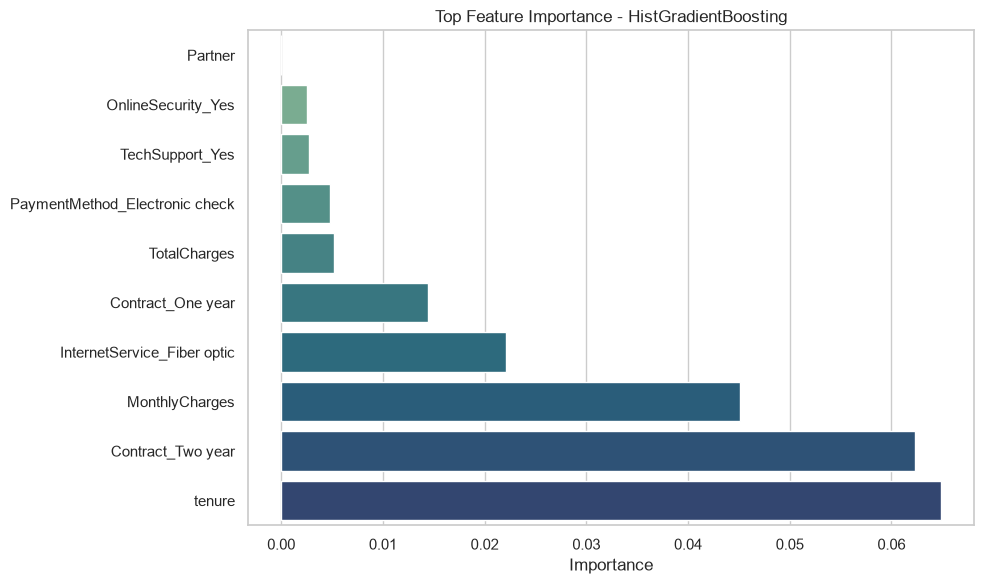

Saved best model to: c:\Users\AHMED SAMIR\Desktop\AI&Data_Science\DS_project\customer-churn-prediction\artifacts\model_experimentation\models\best_churn_model.joblib


In [8]:
best_preprocessor = best_pipeline.named_steps['preprocessor']
best_model = best_pipeline.named_steps['model']

if hasattr(best_model, 'feature_importances_'):
    importance_values = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance_values = np.abs(best_model.coef_).ravel()
else:
    perm = permutation_importance(
        best_pipeline,
        X_test,
        y_test,
        scoring='roc_auc',
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_values = perm.importances_mean

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values,
}).sort_values('Importance', ascending=False)

display(feature_importance_df.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance_df.head(15).iloc[::-1]
sns.barplot(data=top_features, y='Feature', x='Importance', ax=ax, palette='crest')
ax.set_title(f'Top Feature Importance - {best_model_name}')
ax.set_xlabel('Importance')
ax.set_ylabel('')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'feature_importance.png', dpi=180, bbox_inches='tight')
plt.show()

joblib.dump(best_pipeline, MODEL_DIR / 'best_churn_model.joblib')
joblib.dump(best_preprocessor, MODEL_DIR / 'preprocessing_pipeline.joblib')
joblib.dump({
    'feature_names': feature_names,
    'target_name': 'Churn',
    'best_model_name': best_model_name,
    'best_parameters': best_model_bundle['search'].best_params_,
}, MODEL_DIR / 'model_metadata.joblib')

print('Saved best model to:', MODEL_DIR / 'best_churn_model.joblib')

In [9]:
dataset_summary = {
    'samples': int(df.shape[0]),
    'features': int(X.shape[1]),
    'target_positive_rate': float(y.mean()),
}

summary_table = results_df[['Model Name', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV Score', 'Training Time', 'Prediction Time']].copy()
summary_table = summary_table.round({
    'Accuracy': 4,
    'Precision': 4,
    'Recall': 4,
    'F1 Score': 4,
    'ROC-AUC': 4,
    'CV Score': 4,
    'Training Time': 2,
    'Prediction Time': 4,
})

report_lines = [
    '# Final Model Development Report',
    '',
    '## Dataset Summary',
    f"- Number of samples: {dataset_summary['samples']}",
    f"- Number of features: {dataset_summary['features']}",
    f"- Positive churn rate: {dataset_summary['target_positive_rate']:.4f}",
    '',
    '## Training Summary',
    f'- Models trained: {len(results_df)}',
    '- Hyperparameter tuning method: RandomizedSearchCV',
    '- Cross-validation strategy: StratifiedKFold with 5 folds',
    '',
    '## Results Summary',
    summary_table.to_string(index=False),
    '',
    '## Best Model Analysis',
    f'- Selected model: {best_model_name}',
    f"- Best ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}",
    f"- Best F1 Score: {results_df.iloc[0]['F1 Score']:.4f}",
    f"- Best CV Score: {results_df.iloc[0]['CV Score']:.4f}",
    '',
    '## Feature Importance Analysis',
    feature_importance_df.head(10).to_string(index=False),
    '',
    '## Recommendations',
    '- Deploy the saved joblib pipeline behind a batch or online inference service.',
    '- Monitor calibration, data drift, and class-imbalance metrics over time.',
    '- Re-train periodically with newly collected churn outcomes.',
]

report_text = '\n'.join(report_lines)
(ARTIFACT_DIR / 'final_report.md').write_text(report_text, encoding='utf-8')
display(Markdown(report_text))

# Final Model Development Report

## Dataset Summary
- Number of samples: 7032
- Number of features: 10
- Positive churn rate: 0.2658

## Training Summary
- Models trained: 20
- Hyperparameter tuning method: RandomizedSearchCV
- Cross-validation strategy: StratifiedKFold with 5 folds

## Results Summary
          Model Name  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV Score  Training Time  Prediction Time
HistGradientBoosting    0.7953     0.6443  0.5134    0.5714   0.8380    0.8464           9.13           0.0141
            AdaBoost    0.7960     0.6526  0.4973    0.5645   0.8367    0.8434          10.26           0.0624
   Gradient Boosting    0.7896     0.6309  0.5027    0.5595   0.8365    0.8458          11.94           0.0030
 Stacking Classifier    0.7861     0.6237  0.4920    0.5501   0.8359    0.8456         133.92           0.0657
       Random Forest    0.7420     0.5095  0.7861    0.6183   0.8349    0.8431          31.00           0.1079
             XGBoost    0.7861     0.6151  0.5214    0.5644   0.8347    0.8459          15.87           0.0066
   Voting Classifier    0.7875     0.6214  0.5134    0.5622   0.8343    0.8438          11.36           0.0556
      MLP Classifier    0.7910     0.6325  0.5107    0.5651   0.8304    0.8407          41.54           0.0023
         Extra Trees    0.7285     0.4933  0.7861    0.6062   0.8303    0.8406          23.05           0.0928
 Logistic Regression    0.7846     0.6149  0.5080    0.5564   0.8303    0.8390           5.03           0.0056
      SGD Classifier    0.7832     0.6202  0.4759    0.5386   0.8300    0.8365           0.72           0.0021
          Linear SVM    0.7242     0.4885  0.7968    0.6057   0.8273    0.8379           0.37           0.0034
    Ridge Classifier    0.7242     0.4884  0.7914    0.6041   0.8256    0.8368           0.26           0.0040
             RBF SVM    0.6631     0.4324  0.8556    0.5745   0.8236    0.8344          66.40           0.3694
       Decision Tree    0.7804     0.6109  0.4786    0.5367   0.8167    0.8312           0.48           0.0016
         Gaussian NB    0.7178     0.4814  0.7941    0.5994   0.8166    0.8270           0.20           0.0026
        Bernoulli NB    0.7733     0.5676  0.6176    0.5915   0.8108    0.8179           0.33           0.0065
  Passive Aggressive    0.7491     0.5248  0.5936    0.5571   0.8046    0.7672           0.29           0.0030
                 KNN    0.7747     0.5947  0.4786    0.5304   0.8027    0.8135           0.89           0.0413
  Bagging Classifier    0.7640     0.5705  0.4545    0.5060   0.8004    0.8148          10.03           0.1331

## Best Model Analysis
- Selected model: HistGradientBoosting
- Best ROC-AUC: 0.8380
- Best F1 Score: 0.5714
- Best CV Score: 0.8464

## Feature Importance Analysis
                       Feature  Importance
                        tenure    0.064870
             Contract_Two year    0.062342
                MonthlyCharges    0.045102
   InternetService_Fiber optic    0.022133
             Contract_One year    0.014464
                  TotalCharges    0.005240
PaymentMethod_Electronic check    0.004833
               TechSupport_Yes    0.002752
            OnlineSecurity_Yes    0.002508
                       Partner   -0.000002

## Recommendations
- Deploy the saved joblib pipeline behind a batch or online inference service.
- Monitor calibration, data drift, and class-imbalance metrics over time.
- Re-train periodically with newly collected churn outcomes.